# EC 9560 – Lab 3: Data Pre-Processing
**Laptop Price Prediction using Hardware Specifications**

NAME: NAFRAS M.N.A. | REG NO: 2020/E/102 | SEM: 07

This notebook takes the raw `laptop_price.csv` (1,303 rows, 13 columns) and produces:
- `laptop_price_engineered.csv` — cleaned, decomposed, human-readable
- `laptop_price_model_ready.csv` — one-hot encoded + scaled, ready for modelling

## 0. Imports and raw data load

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.width', 140)

df = pd.read_csv('laptop_price.csv', encoding='latin-1')
raw_shape = df.shape
print('Raw shape:', raw_shape)
df.head()

Raw shape: (1303, 13)


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


## 1. Ram and Weight → numeric
Both are stored as text with a unit suffix (`"8GB"`, `"1.37kg"`). Strip the suffix and cast.

In [2]:
df['Ram_GB'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)
df['Weight_kg'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)

df[['Ram', 'Ram_GB', 'Weight', 'Weight_kg']].head()

,Ram,Ram_GB,Weight,Weight_kg
0,8GB,8,1.37kg,1.37
1,8GB,8,1.34kg,1.34
2,8GB,8,1.86kg,1.86
3,16GB,16,1.83kg,1.83
4,8GB,8,1.37kg,1.37


## 2. Memory → storage-type capacities
`Memory` can hold up to two devices joined with `+` (e.g. `"256GB SSD +  1TB HDD"`), in either GB or TB. Parse each chunk and accumulate by storage type.

In [3]:
def parse_memory(mem):
    parts = [p.strip() for p in mem.split('+')]
    out = {'SSD_GB': 0, 'HDD_GB': 0, 'Flash_Storage_GB': 0, 'Hybrid_GB': 0}
    for p in parts:
        m = re.search(r'([\d.]+)\s*(GB|TB)', p)
        if not m:
            continue
        size = float(m.group(1))
        if m.group(2) == 'TB':
            size *= 1000
        if 'SSD' in p:
            out['SSD_GB'] += size
        elif 'HDD' in p:
            out['HDD_GB'] += size
        elif 'Flash Storage' in p:
            out['Flash_Storage_GB'] += size
        elif 'Hybrid' in p:
            out['Hybrid_GB'] += size
    return pd.Series(out)

mem_df = df['Memory'].apply(parse_memory)
df = pd.concat([df, mem_df], axis=1)
df['Total_Storage_GB'] = df[['SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']].sum(axis=1)

print('Laptops with each storage type present:')
for c in ['SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']:
    print(f'  {c}: {(df[c] > 0).sum()}')

df[['Memory', 'SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB', 'Total_Storage_GB']].head()

Laptops with each storage type present:
  SSD_GB: 843
  HDD_GB: 576
  Flash_Storage_GB: 75
  Hybrid_GB: 12


,Memory,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB,Total_Storage_GB
0,128GB SSD,128.0,0.0,0.0,0.0,128.0
1,128GB Flash Storage,0.0,0.0,128.0,0.0,128.0
2,256GB SSD,256.0,0.0,0.0,0.0,256.0
3,512GB SSD,512.0,0.0,0.0,0.0,512.0
4,256GB SSD,256.0,0.0,0.0,0.0,256.0


**Figure: storage-type prevalence and total storage distribution**

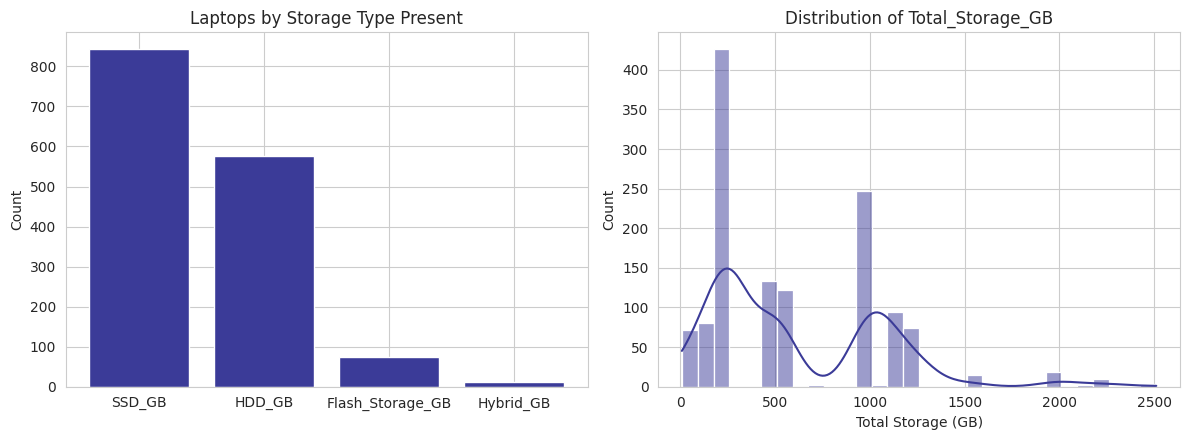

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

storage_counts = {c: (df[c] > 0).sum() for c in ['SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']}
axes[0].bar(storage_counts.keys(), storage_counts.values(), color='#3b3b98')
axes[0].set_title('Laptops by Storage Type Present')
axes[0].set_ylabel('Count')

sns.histplot(df['Total_Storage_GB'], bins=30, kde=True, ax=axes[1], color='#3b3b98')
axes[1].set_title('Distribution of Total_Storage_GB')
axes[1].set_xlabel('Total Storage (GB)')

plt.tight_layout()
plt.show()

## 3. Cpu → brand, series/type, clock speed

In [5]:
def cpu_brand(cpu):
    return cpu.split()[0]

def cpu_type(cpu):
    if 'Intel Core i7' in cpu:
        return 'Intel Core i7'
    if 'Intel Core i5' in cpu:
        return 'Intel Core i5'
    if 'Intel Core i3' in cpu:
        return 'Intel Core i3'
    if cpu.split()[0] == 'Intel':
        return 'Other Intel Processor'
    if cpu.split()[0] == 'AMD':
        return 'AMD Processor'
    return 'Other'

df['Cpu_brand'] = df['Cpu'].apply(cpu_brand)
df['Cpu_type'] = df['Cpu'].apply(cpu_type)
df['Cpu_speed_GHz'] = df['Cpu'].str.extract(r'([\d.]+)GHz').astype(float)

print(df['Cpu_type'].value_counts())
df[['Cpu', 'Cpu_brand', 'Cpu_type', 'Cpu_speed_GHz']].head()

Cpu_type
Intel Core i7            527
Intel Core i5            423
Other Intel Processor    154
Intel Core i3            136
AMD Processor             62
Other                      1
Name: count, dtype: int64


,Cpu,Cpu_brand,Cpu_type,Cpu_speed_GHz
0,Intel Core i5 2.3GHz,Intel,Intel Core i5,2.3
1,Intel Core i5 1.8GHz,Intel,Intel Core i5,1.8
2,Intel Core i5 7200U 2.5GHz,Intel,Intel Core i5,2.5
3,Intel Core i7 2.7GHz,Intel,Intel Core i7,2.7
4,Intel Core i5 3.1GHz,Intel,Intel Core i5,3.1


**Figure: Cpu_type breakdown and clock speed distribution**

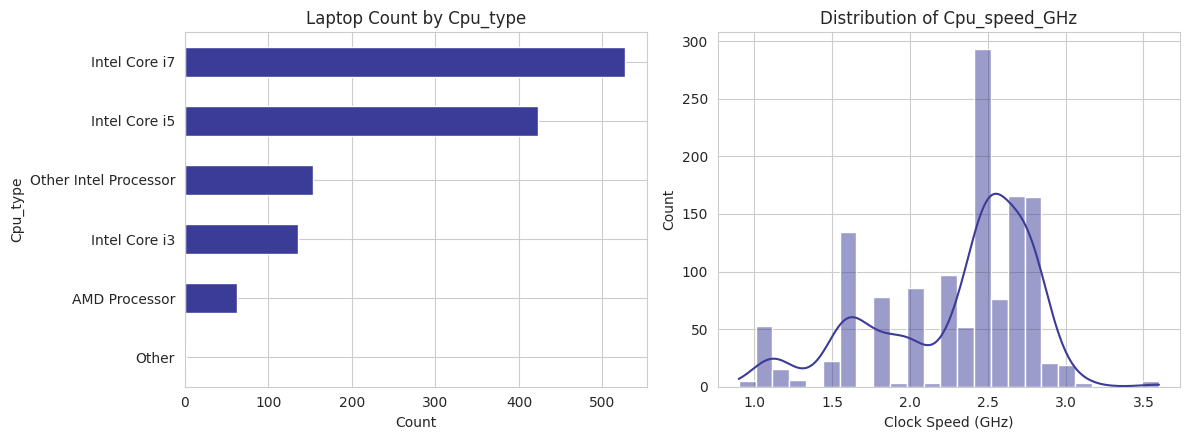

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df['Cpu_type'].value_counts().plot(kind='barh', ax=axes[0], color='#3b3b98')
axes[0].set_title('Laptop Count by Cpu_type')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

sns.histplot(df['Cpu_speed_GHz'], bins=25, kde=True, ax=axes[1], color='#3b3b98')
axes[1].set_title('Distribution of Cpu_speed_GHz')
axes[1].set_xlabel('Clock Speed (GHz)')

plt.tight_layout()
plt.show()

## 4. Gpu → brand

In [7]:
df['Gpu_brand'] = df['Gpu'].apply(lambda x: x.split()[0])
print(df['Gpu_brand'].value_counts())

Gpu_brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64


## 5. ScreenResolution → width, height, PPI, Touchscreen, IPS panel

In [8]:
res = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)')
df['Screen_Width'] = res[0].astype(int)
df['Screen_Height'] = res[1].astype(int)
df['PPI'] = (((df['Screen_Width']**2 + df['Screen_Height']**2) ** 0.5) / df['Inches']).round(2)
df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen').astype(int)
df['IPS_Panel'] = df['ScreenResolution'].str.contains('IPS Panel').astype(int)

df[['ScreenResolution', 'Screen_Width', 'Screen_Height', 'PPI', 'Touchscreen', 'IPS_Panel']].head()

,ScreenResolution,Screen_Width,Screen_Height,PPI,Touchscreen,IPS_Panel
0,IPS Panel Retina Display 2560x1600,2560,1600,226.98,0,1
1,1440x900,1440,900,127.68,0,0
2,Full HD 1920x1080,1920,1080,141.21,0,0
3,IPS Panel Retina Display 2880x1800,2880,1800,220.53,0,1
4,IPS Panel Retina Display 2560x1600,2560,1600,226.98,0,1


**Figure: Gpu brand split, PPI distribution, and display-type flags**

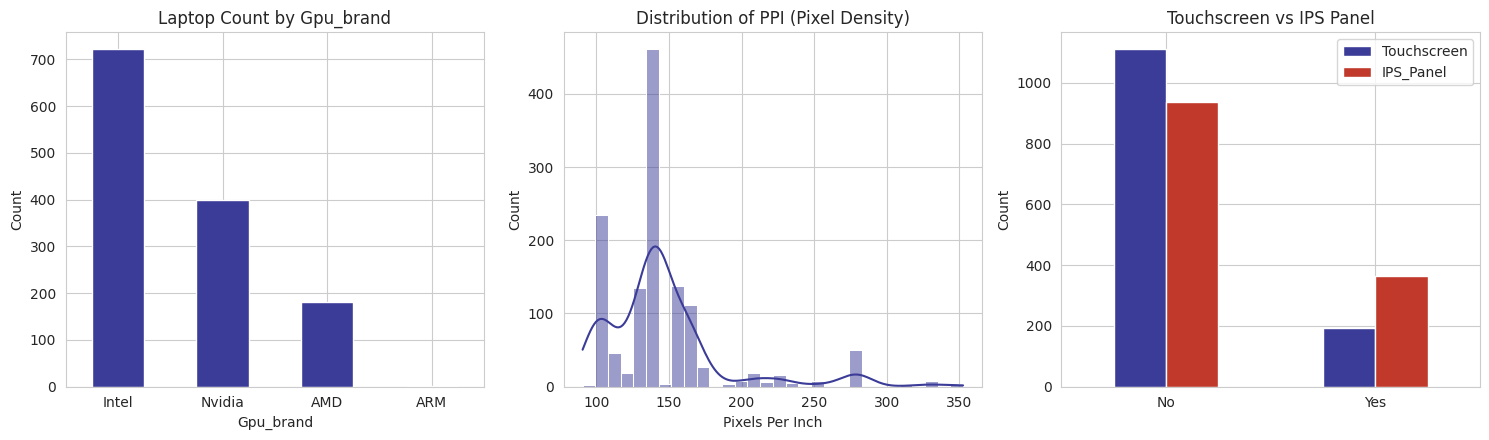

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

df['Gpu_brand'].value_counts().plot(kind='bar', ax=axes[0], color='#3b3b98')
axes[0].set_title('Laptop Count by Gpu_brand')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

sns.histplot(df['PPI'], bins=30, kde=True, ax=axes[1], color='#3b3b98')
axes[1].set_title('Distribution of PPI (Pixel Density)')
axes[1].set_xlabel('Pixels Per Inch')

flags = pd.DataFrame({
    'Touchscreen': df['Touchscreen'].value_counts().sort_index(),
    'IPS_Panel': df['IPS_Panel'].value_counts().sort_index()
}).rename(index={0: 'No', 1: 'Yes'})
flags.plot(kind='bar', ax=axes[2], color=['#3b3b98', '#c0392b'])
axes[2].set_title('Touchscreen vs IPS Panel')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. OpSys → group macOS variants
Merge `Mac OS X` into `macOS`, matching Lab 2's combined count of 21.

In [10]:
df['OpSys_grouped'] = df['OpSys'].replace({'Mac OS X': 'macOS'})
df['OpSys_grouped'].value_counts()

OpSys_grouped
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             21
Windows 10 S       8
Android            2
Name: count, dtype: int64

**Figure: OpSys_grouped distribution**

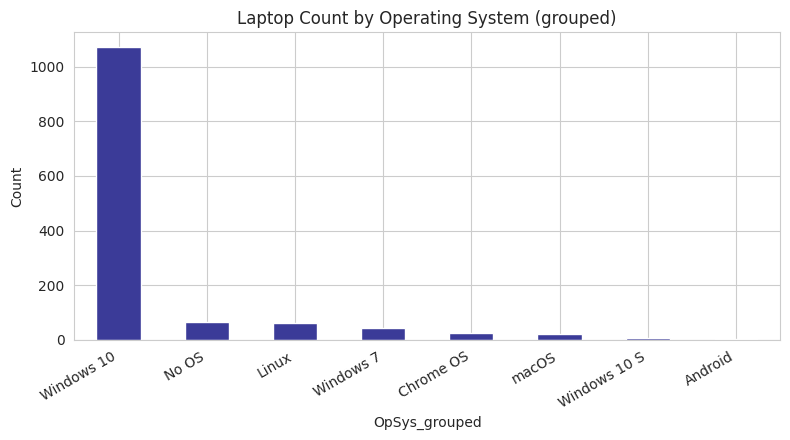

In [11]:
plt.figure(figsize=(8, 4.5))
df['OpSys_grouped'].value_counts().plot(kind='bar', color='#3b3b98')
plt.title('Laptop Count by Operating System (grouped)')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 7. Target variable → log transform
Lab 2 measured `Price_euros` skewness at ≈1.52. Check the improvement from `log1p`.

In [12]:
df['Price_log'] = np.log1p(df['Price_euros'])

print('Skew raw :', df['Price_euros'].skew().round(3))
print('Skew log :', df['Price_log'].skew().round(3))

Skew raw : 1.521
Skew log : -0.172


**Figure: Price_euros before vs. after the log transform**

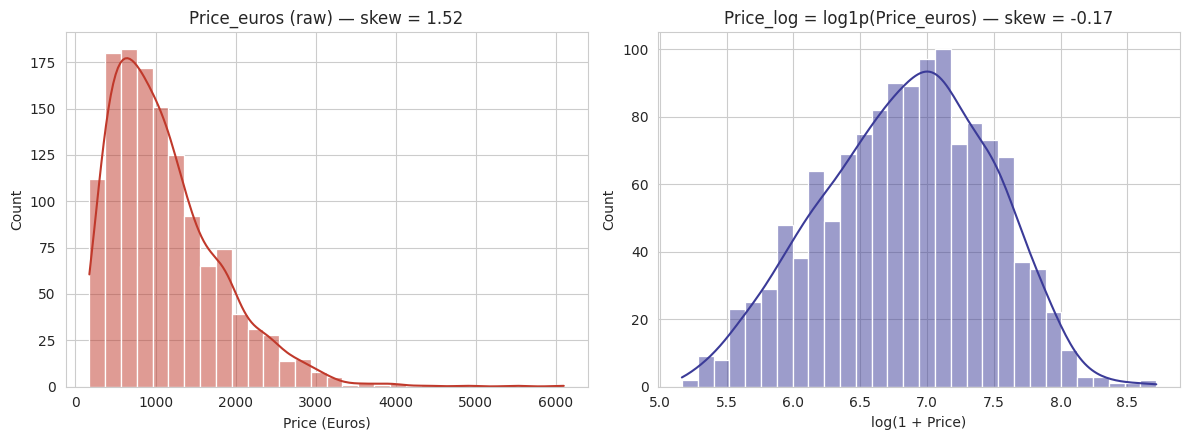

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df['Price_euros'], bins=30, kde=True, ax=axes[0], color='#c0392b')
axes[0].set_title(f"Price_euros (raw) — skew = {df['Price_euros'].skew():.2f}")
axes[0].set_xlabel('Price (Euros)')

sns.histplot(df['Price_log'], bins=30, kde=True, ax=axes[1], color='#3b3b98')
axes[1].set_title(f"Price_log = log1p(Price_euros) — skew = {df['Price_log'].skew():.2f}")
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

## 8. Drop raw/redundant text columns → engineered dataset
`Inches` and `Weight_kg` are **kept** despite their collinearity (flagged in Lab 2) — dropping features is deferred to the Lab 4 feature-selection stage.

In [14]:
engineered = df.drop(columns=['Ram', 'Weight', 'Memory', 'Cpu', 'Gpu',
                               'ScreenResolution', 'OpSys', 'laptop_ID', 'Product'])

print('Engineered shape:', engineered.shape)
print('Missing values:', engineered.isna().sum().sum())

engineered.to_csv('laptop_price_engineered.csv', index=False)
engineered.head()

Engineered shape: (1303, 22)
Missing values: 0


,Company,TypeName,Inches,Price_euros,Ram_GB,Weight_kg,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB,...,Cpu_type,Cpu_speed_GHz,Gpu_brand,Screen_Width,Screen_Height,PPI,Touchscreen,IPS_Panel,OpSys_grouped,Price_log
0,Apple,Ultrabook,13.3,1339.69,8,1.37,128.0,0.0,0.0,0.0,...,Intel Core i5,2.3,Intel,2560,1600,226.98,0,1,macOS,7.200940
1,Apple,Ultrabook,13.3,898.94,8,1.34,0.0,0.0,128.0,0.0,...,Intel Core i5,1.8,Intel,1440,900,127.68,0,0,macOS,6.802328
2,HP,Notebook,15.6,575.00,8,1.86,256.0,0.0,0.0,0.0,...,Intel Core i5,2.5,Intel,1920,1080,141.21,0,0,No OS,6.356108
3,Apple,Ultrabook,15.4,2537.45,16,1.83,512.0,0.0,0.0,0.0,...,Intel Core i7,2.7,AMD,2880,1800,220.53,0,1,macOS,7.839309
4,Apple,Ultrabook,13.3,1803.60,8,1.37,256.0,0.0,0.0,0.0,...,Intel Core i5,3.1,Intel,2560,1600,226.98,0,1,macOS,7.498094


## 9. Validate: correlation of engineered features with price
Confirms the decomposition in steps 2–5 surfaced predictors that weren't visible in Lab 2's raw-column correlation matrix.

In [15]:
corr_cols = ['Ram_GB', 'Weight_kg', 'Inches', 'SSD_GB', 'HDD_GB', 'Flash_Storage_GB',
             'Total_Storage_GB', 'Cpu_speed_GHz', 'PPI', 'Touchscreen', 'IPS_Panel', 'Price_euros']
engineered[corr_cols].corr()['Price_euros'].sort_values(ascending=False)

Price_euros         1.000000
Ram_GB              0.743007
SSD_GB              0.670799
PPI                 0.473506
Cpu_speed_GHz       0.430293
IPS_Panel           0.252208
Weight_kg           0.210370
Touchscreen         0.191226
Total_Storage_GB    0.160819
Inches              0.068197
Flash_Storage_GB   -0.040511
HDD_GB             -0.096441
Name: Price_euros, dtype: float64

**Figure: correlation heatmap of engineered numeric features**

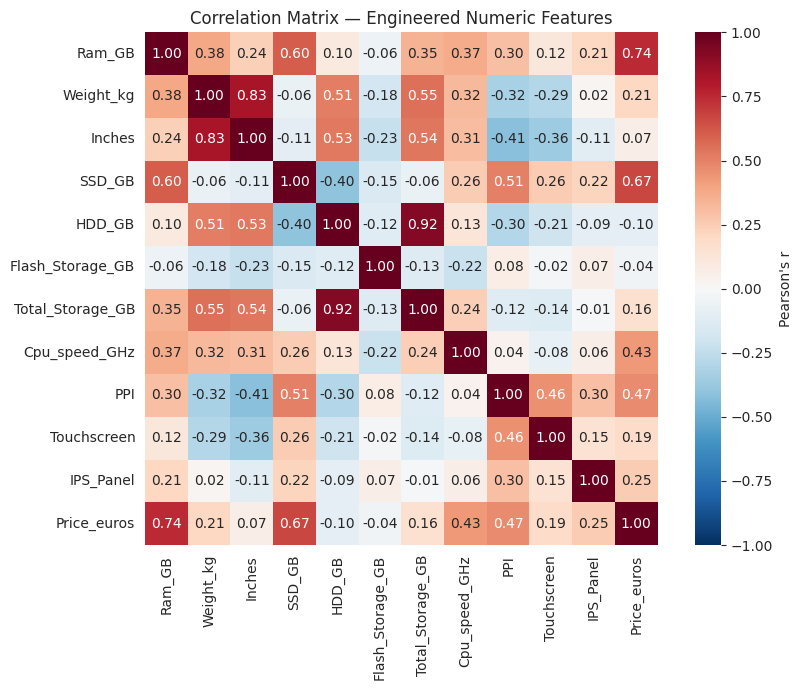

In [16]:
plt.figure(figsize=(9, 7))
sns.heatmap(engineered[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, cbar_kws={'label': "Pearson's r"})
plt.title('Correlation Matrix — Engineered Numeric Features')
plt.tight_layout()
plt.show()

**Figure: top new predictors vs Price_euros**

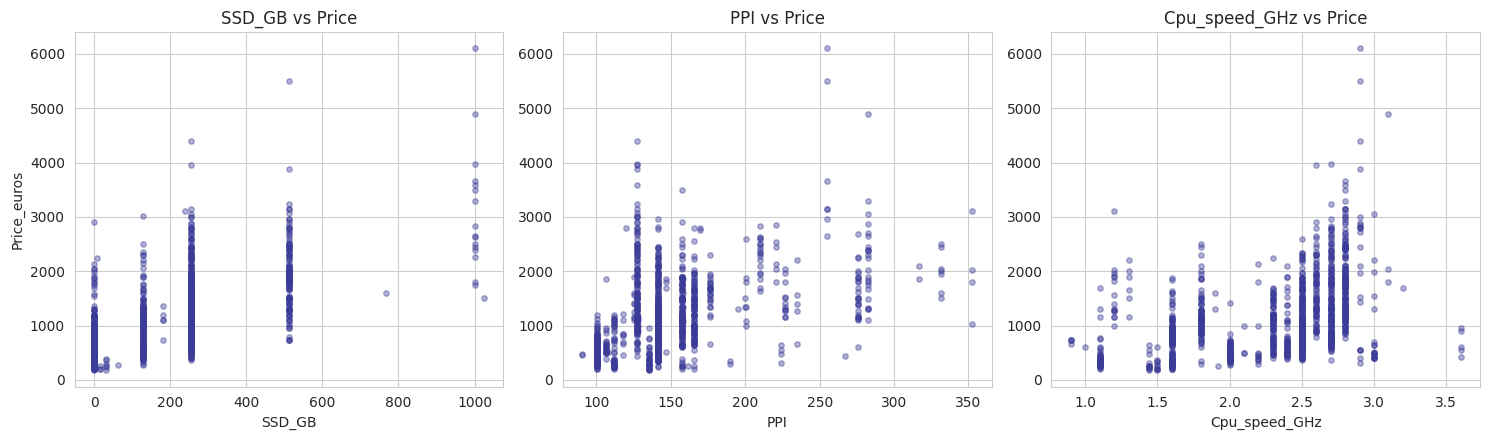

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(engineered['SSD_GB'], engineered['Price_euros'], alpha=0.4, color='#3b3b98', s=15)
axes[0].set_xlabel('SSD_GB')
axes[0].set_ylabel('Price_euros')
axes[0].set_title('SSD_GB vs Price')

axes[1].scatter(engineered['PPI'], engineered['Price_euros'], alpha=0.4, color='#3b3b98', s=15)
axes[1].set_xlabel('PPI')
axes[1].set_title('PPI vs Price')

axes[2].scatter(engineered['Cpu_speed_GHz'], engineered['Price_euros'], alpha=0.4, color='#3b3b98', s=15)
axes[2].set_xlabel('Cpu_speed_GHz')
axes[2].set_title('Cpu_speed_GHz vs Price')

plt.tight_layout()
plt.show()

## 10. Encode categoricals + scale numerics → model-ready dataset
One-Hot Encoding (drop-first) for the six categorical columns, then `StandardScaler` on the continuous numeric columns. Binary flags and one-hot columns are left unscaled.

In [18]:
from sklearn.preprocessing import StandardScaler

cat_cols = ['Company', 'TypeName', 'OpSys_grouped', 'Cpu_brand', 'Cpu_type', 'Gpu_brand']
num_cols = ['Inches', 'Ram_GB', 'Weight_kg', 'SSD_GB', 'HDD_GB', 'Flash_Storage_GB',
            'Hybrid_GB', 'Total_Storage_GB', 'Cpu_speed_GHz', 'Screen_Width',
            'Screen_Height', 'PPI']

model_df = pd.get_dummies(engineered, columns=cat_cols, drop_first=True)

scaler = StandardScaler()
model_df[num_cols] = scaler.fit_transform(model_df[num_cols])

print('Model-ready shape:', model_df.shape)
model_df.to_csv('laptop_price_model_ready.csv', index=False)
model_df.head()

Model-ready shape: (1303, 56)


,Inches,Price_euros,Ram_GB,Weight_kg,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB,Total_Storage_GB,Cpu_speed_GHz,...,Cpu_brand_Intel,Cpu_brand_Samsung,Cpu_type_Intel Core i3,Cpu_type_Intel Core i5,Cpu_type_Intel Core i7,Cpu_type_Other,Cpu_type_Other Intel Processor,Gpu_brand_ARM,Gpu_brand_Intel,Gpu_brand_Nvidia
0,-1.204407,1339.69,-0.075195,-1.005283,-0.298204,-0.802496,-0.150538,-0.095448,-1.033327,0.002426,...,True,False,False,True,False,False,False,False,True,False
1,-1.204407,898.94,-0.075195,-1.050381,-0.983080,-0.802496,4.079124,-0.095448,-1.033327,-0.985431,...,True,False,False,True,False,False,False,False,True,False
2,0.408772,575.00,-0.075195,-0.268684,0.386672,-0.802496,-0.150538,-0.095448,-0.759430,0.397569,...,True,False,False,True,False,False,False,False,True,False
3,0.268495,2537.45,1.498767,-0.313782,1.756424,-0.802496,-0.150538,-0.095448,-0.211637,0.792712,...,True,False,False,False,True,False,False,False,False,False
4,-1.204407,1803.60,-0.075195,-1.005283,0.386672,-0.802496,-0.150538,-0.095448,-0.759430,1.582997,...,True,False,False,True,False,False,False,False,True,False


## 11. Summary
| Stage | Rows | Columns | Missing |
|---|---|---|---|
| Raw | 1,303 | 13 | 0 |
| Engineered | 1,303 | 22 | 0 |
| Model-ready | 1,303 | 56 | 0 |

**Going into Lab 4:** test `Inches`/`Weight_kg` collinearity (VIF or correlation threshold), consider dropping/transforming `HDD_GB` and `Flash_Storage_GB` (near-zero/negative correlation), and prioritise `SSD_GB`, `PPI`, and `Cpu_speed_GHz` as strong predictors.